# About Dataset
The price of a car depends on a lot of factors like the goodwill of the brand of the car, features of the car, horsepower and the mileage it gives and many more. Car price prediction is one of the major research areas in machine learning. So if you want to learn how to train a car price prediction model

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [116]:
df = pd.read_csv('cardata.csv')

In [117]:
print("\nHead:")
df.head()


Head:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [118]:
# Shape (rows, columns)
print("Shape:", df.shape)

Shape: (301, 9)


In [119]:
# Data info (types + non-null counts)
print("\nInfo:")
df.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [120]:
# Descriptive stats (numeric columns by default)
print("\nDescribe (numeric):")
df.describe(include="number")


Describe (numeric):


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [121]:
# Describe categorical columns too
print("\nDescribe (categorical):")
df.describe(include="object")


Describe (categorical):


,Car_Name,Fuel_Type,Selling_type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


In [122]:
#  Missing values as % of total rows
print("\nMissing values (%):")
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing[missing > 0].round(2)


Missing values (%):


Series([], dtype: float64)

In [123]:
# check duplicates
df.duplicated().sum()

np.int64(2)

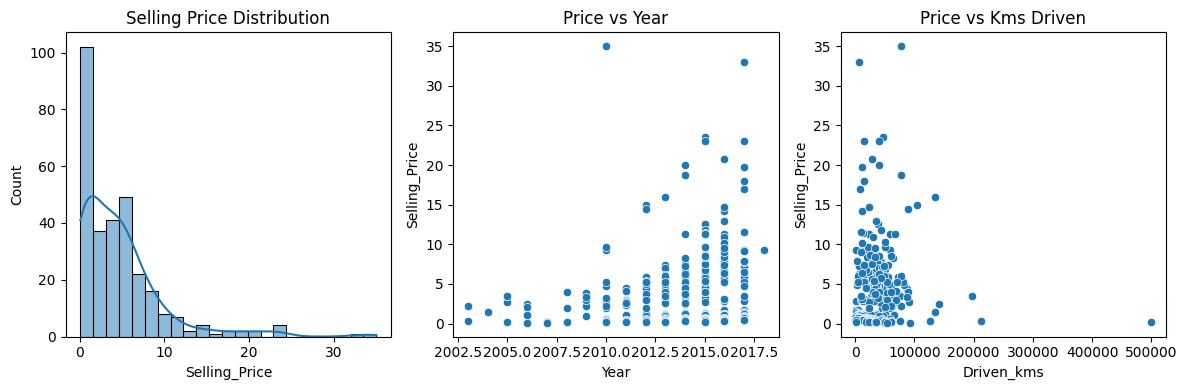

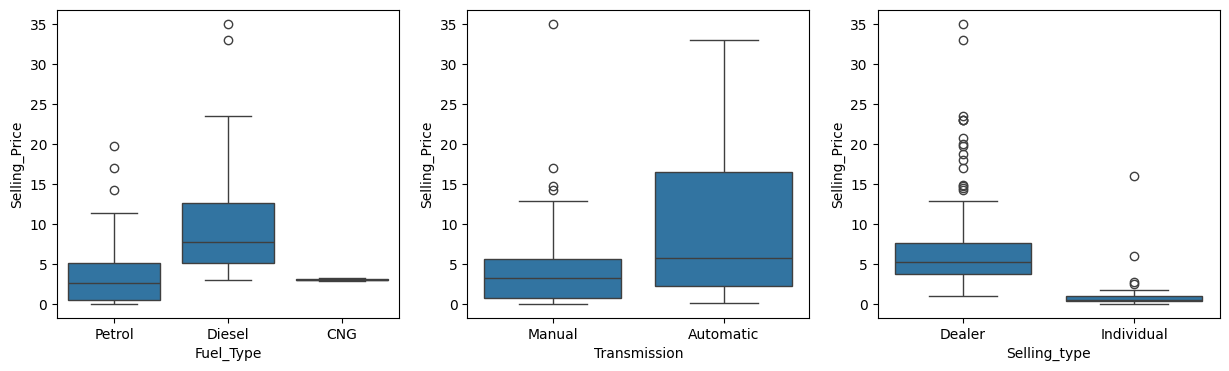

In [124]:
# Distribution of target variable
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Selling Price Distribution')

# Price vs Year
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Year', y='Selling_Price')
plt.title('Price vs Year')

# Price vs Driven_kms
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Driven_kms', y='Selling_Price')
plt.title('Price vs Kms Driven')
plt.tight_layout()
plt.show()

# Categorical feature impact
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', ax=axes[0])
sns.boxplot(data=df, x='Transmission', y='Selling_Price', ax=axes[1])
sns.boxplot(data=df, x='Selling_type', y='Selling_Price', ax=axes[2])
plt.show()

In [125]:
# Extract brand from Car_Name (first word)
df['Brand'] = df['Car_Name'].str.split().str[0]

# Car age (current year - manufacturing year)
df['Car_Age'] = 2025 - df['Year']

# Brand goodwill: average price per brand (computed on training data only to avoid leakage)
# We'll do this after train-test split in practice.

# Drop original Car_Name and Year (replaced by Car_Age)
# df = df.drop(['Car_Name', 'Year'], axis=1)

In [126]:
print(df['Brand'].nunique())

df['Brand'].unique()

44


array(['ritz', 'sx4', 'ciaz', 'wagon', 'swift', 'vitara', 's', 'alto',
       'ertiga', 'dzire', 'ignis', '800', 'baleno', 'omni', 'fortuner',
       'innova', 'corolla', 'etios', 'camry', 'land', 'Royal', 'UM',
       'KTM', 'Bajaj', 'Hyosung', 'Mahindra', 'Honda', 'Yamaha', 'TVS',
       'Hero', 'Activa', 'Suzuki', 'i20', 'grand', 'i10', 'eon', 'xcent',
       'elantra', 'creta', 'verna', 'city', 'brio', 'amaze', 'jazz'],
      dtype=object)

In [127]:
# Brand column values UM, KTM,Yamaha,TVS, Activa convert into bikes
df['Brand'] = df['Brand'].replace(['UM','KTM','Yamaha','TVS','Activa'],'bikes')

In [128]:
# Brand column if less than 10 values convert into others
counts = df['Brand'].value_counts()
rare_brands = counts[counts < 10].index
df['Brand'] = df['Brand'].replace(rare_brands, 'rare_brands')

In [129]:
df.head(2)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Brand,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,rare_brands,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,rare_brands,12


In [130]:
df = df.drop(["Car_Name", "Year"], axis=1)

In [131]:
# ---------- 1. Create variable X ----------
X = df.drop("Selling_Price", axis=1)

# ---------- 2. Create variable X ----------
y = df["Selling_Price"]

# ---------- 3. Split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- 4. Brand goodwill (fit on TRAIN only, no leakage) ----------
brand_goodwill = (
    X_train.assign(Selling_Price=y_train)
    .groupby("Brand")["Selling_Price"]
    .mean()
    .to_dict()
)
global_mean = float(y_train.mean())

X_train["Brand_Goodwill"] = (
    X_train["Brand"].map(brand_goodwill).fillna(global_mean)
)
X_test["Brand_Goodwill"] = (
    X_test["Brand"].map(brand_goodwill).fillna(global_mean)
)

# ---------- 5. Preprocessing ----------
num_cols = ["Present_Price", "Driven_kms", "Owner", "Car_Age", "Brand_Goodwill"]
cat_cols = ["Fuel_Type", "Selling_type", "Transmission", "Brand"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# ---------- 6. Candidate models ----------
candidates = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=12, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42
    ),
}

# ---------- 7. Evaluate & pick best ----------
best_name, best_pipe, best_r2 = None, None, -np.inf

print(f"{'Model':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 48)

for name, model in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"{name:<20} {mae:>8.3f} {rmse:>8.3f} {r2:>8.3f}")

    if r2 > best_r2:
        best_r2, best_name, best_pipe = r2, name, pipe

print(f"\n✅ Best model: {best_name}  (R² = {best_r2:.4f})")

# ---------- 8. Save artifacts ----------
joblib.dump(best_pipe, "model.pkl")
joblib.dump(brand_goodwill, "brand_goodwill.pkl")
joblib.dump(global_mean, "global_mean.pkl")

print("💾 Saved: model.pkl, brand_goodwill.pkl, global_mean.pkl")

Model                     MAE     RMSE       R²
------------------------------------------------
Linear Regression       1.090    1.740    0.869
Ridge                   1.094    1.745    0.868
Random Forest           0.606    0.915    0.964
Gradient Boosting       0.498    0.761    0.975

✅ Best model: Gradient Boosting  (R² = 0.9749)
💾 Saved: model.pkl, brand_goodwill.pkl, global_mean.pkl
